Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3084 - Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa Vela (23764)

# Laboratorio 6: Análisis de Redes Sociales en YouTube

## Notebook 4 - Sentimientos, interpretación y conclusiones

Este notebook resuelve los **Ejercicios 9 y 10** del laboratorio.

Los notebooks anteriores describieron **quién participa** y **cómo se conecta**. Aquí se analiza **qué se dice y con qué carga emocional**, y se integra todo en una interpretación que detalla hasta dónde llegan estos datos.

**Preparación del entorno**

In [1]:
import re
import sys
import warnings
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src.utils import DATA_PROCESSED, DATA_RAW, cargar, guardar, set_estilo

set_estilo()
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

cv = cargar("comentarios_videos")
comunidades = pd.read_csv(DATA_PROCESSED / "comunidades_nodos.csv")

# Se recupera la comunidad detectada en el Ejercicio 7 para cada comentario
com_autor = comunidades.set_index("node_id")["comunidad"].to_dict()
cv["comunidad"] = cv["author_channel_id"].map(com_autor)
cv["comunidad_video"] = cv["video_id"].map(com_autor)

print("comentarios:", len(cv), "| comunidades cargadas:", comunidades["comunidad"].nunique())

comentarios: 406 | comunidades cargadas: 17


## Ejercicio 9. Análisis de contenido y sentimiento

### 9.1 Elección de la herramienta

El análisis se hace sobre **`texto_original`** como se había previsto antes. Se evalúan **dos enfoques** y se elige con evidencia.

In [2]:
# ENFOQUE 1 — Léxico de polaridad ML-SentiCon (Cruz et al., 2014).
# Asigna a cada lema una polaridad entre -1 y 1. Se usa la capa 8, la de mayor cobertura.
raiz = ET.parse(DATA_RAW / "senticon.es.xml").getroot()
lexico = {}
for capa in raiz.findall("layer"):
    for grupo in capa:
        for lema in grupo.findall("lemma"):
            lexico.setdefault(lema.text.strip().lower(), float(lema.get("pol")))

print(f"ML-SentiCon cargado: {len(lexico)} lemas con polaridad")
print("  ejemplos:", {k: lexico[k] for k in list(lexico)[:4]})

ML-SentiCon cargado: 11342 lemas con polaridad
  ejemplos: {'acertado': 0.708, 'admirable': 0.906, 'admiración': 0.45, 'admirar': 0.75}


In [3]:
def puntuar_lexico(tokens):
    """Promedia la polaridad de los lemas del comentario que aparecen en el léxico."""
    vals = [lexico[t] for t in tokens if t in lexico]
    return np.mean(vals) if vals else np.nan


cv["lexico_score"] = cv["tokens_comentario"].map(lambda t: puntuar_lexico(list(t)))
cv["lexico_etiqueta"] = pd.cut(cv["lexico_score"], [-1.01, -0.05, 0.05, 1.01],
                               labels=["NEG", "NEU", "POS"])

todos = [t for lista in cv["tokens_comentario"] for t in lista]
cubiertos = [t for t in todos if t in lexico]

print("COBERTURA DEL LÉXICO")
print(f"  tokens del corpus que están en el léxico: {len(cubiertos)} de {len(todos)} "
      f"({len(cubiertos)/len(todos):.1%})")
print(f"  comentarios con al menos una palabra del léxico: {int(cv['lexico_score'].notna().sum())} "
      f"de {len(cv)} ({cv['lexico_score'].notna().mean():.1%})")
print(f"  comentarios sin ninguna cobertura: {int(cv['lexico_score'].isna().sum())}")

COBERTURA DEL LÉXICO
  tokens del corpus que están en el léxico: 559 de 3857 (14.5%)
  comentarios con al menos una palabra del léxico: 251 de 406 (61.8%)
  comentarios sin ninguna cobertura: 155


In [4]:
# Los comentarios que el léxico considera más positivos y más negativos
muestra = cv.dropna(subset=["lexico_score"])
print("Los 3 comentarios MÁS POSITIVOS según el léxico:")
for _, f in muestra.nlargest(3, "lexico_score").iterrows():
    print(f"  [{f['lexico_score']:+.2f}] {f['texto_original_comentario'][:105]}")
print("\nLos 3 comentarios MÁS NEGATIVOS según el léxico:")
for _, f in muestra.nsmallest(3, "lexico_score").iterrows():
    print(f"  [{f['lexico_score']:+.2f}] {f['texto_original_comentario'][:105]}")

Los 3 comentarios MÁS POSITIVOS según el léxico:
  [+0.81] Magistral información. Que debería ser viral y llegar a toda la población...
  [+0.81] 💯Correcto.  Unicoyote y Telementiras ya jartan con la misma novela y teatro todos los dias.
  [+0.79] Viva nuestra Guatemala bendita y viva nuestro presidente Bernardo Arévalo

Los 3 comentarios MÁS NEGATIVOS según el léxico:
  [-0.88] EL PRESIDENTE BERNARDO AREVALO SI ES UN PRESIDENTE QUE QUIERE A SU PUEBLO Y AL PAIS DE GUATEMALA 👍 EL NO 
  [-0.75] Y CUANDO VAN HABLAR DE LOS GASTOS DEL PRESIDENTE? La carne la bomba de la piscina los salarios exagerados
  [-0.75] Que pena que estos pusilánimes muertos de hambre de poder estén llevando a la Universidad a denigrar la d


**Primer Enfoque: Léxico de Polaridad**

ML-SentiCon aporta 11,342 lemas con polaridad, y cubre el **14.5% de los tokens** del corpus; el 61.8% de los comentarios contiene al menos una de sus palabras. La cobertura, por sí sola, parecería aceptable, pero los ejemplos revelan el problema. Entre los comentarios que el léxico considera **más negativos** aparece *"EL PRESIDENTE BERNARDO AREVALO SI ES UN PRESIDENTE QUE QUIERE A SU PUEBLO Y AL PAIS DE GUATEMALA 👍"*, que es un elogio explícito.

La causa es que un léxico suma palabras sueltas y **no entiende el contexto**; no procesa la negación, ni la ironía, ni el hecho de que *pueblo*, *presidente* o *pena* cambian de signo según la frase. Además, los lemas de ML-SentiCon provienen de WordNet y son de registro formal (incluye entradas como *obliteración*), mientras que aquí la carga emocional la llevan palabras como *corrupto*, *ladrón* o *diputado*.

In [5]:
# ENFOQUE 2 — Modelo RoBERTuito, entrenado con tuits en español anotados (corpus TASS).
# Devuelve una de tres clases (POS/NEU/NEG) con su probabilidad.
from transformers import pipeline

clasificador = pipeline("sentiment-analysis",
                        model="pysentimiento/robertuito-sentiment-analysis",
                        truncation=True, max_length=128)

textos = cv["texto_original_comentario"].astype(str).tolist()
pred = clasificador(textos, batch_size=32)

cv["sentimiento"] = [p["label"] for p in pred]
cv["sentimiento_prob"] = [p["score"] for p in pred]

print("Comentarios clasificados:", int(cv["sentimiento"].notna().sum()), "de", len(cv))
print("\nDistribución de las clases:")
print(cv["sentimiento"].value_counts().to_frame("comentarios")
      .assign(porcentaje=lambda d: (d["comentarios"] / len(cv) * 100).round(1)).to_string())

Device set to use cpu


Comentarios clasificados: 406 de 406

Distribución de las clases:
             comentarios  porcentaje
sentimiento                         
NEG                  250        61.6
POS                   82        20.2
NEU                   74        18.2


**Segundo Enfoque: Modelo Entrenado**

Se usa **RoBERTuito**, un modelo del tipo BERT preentrenado con tuits en español y ajustado para sentimiento con el corpus TASS, que asigna una de tres clases (POS, NEU, NEG). A diferencia del léxico, procesa la frase completa y sí capta la negación y el contexto.

Se eligió por tres razones concretas: (1) fue entrenado en **español**, (2) su dominio de entrenamiento son **mensajes cortos de redes sociales** (exactamente lo que son estos comentarios), y (3) clasifica el **100% de los 406** comentarios.

**Resultado**: **el 61.6% de los comentarios es negativo**, frente a un 20.2% positivo y un 18.2% neutro. La conversación observada es predominantemente crítica.

Probabilidad asignada a la clase elegida
count    406.000
mean       0.820
std        0.158
min        0.355
10%        0.556
25%        0.725
50%        0.883
75%        0.953
max        0.986

Clasificaciones con probabilidad menor a 0.60 (dudosas): 63 (15.5%)


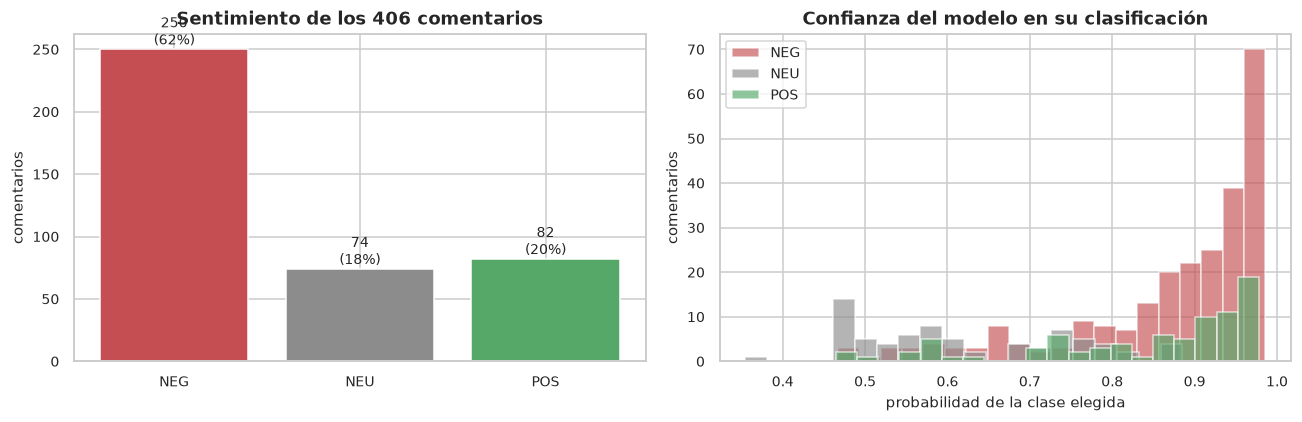

In [6]:
# ¿Qué tan seguras son las clasificaciones?
print("Probabilidad asignada a la clase elegida")
print(cv["sentimiento_prob"].describe([0.1, 0.25, 0.5, 0.75]).round(3).to_string())
print(f"\nClasificaciones con probabilidad menor a 0.60 (dudosas): "
      f"{int((cv['sentimiento_prob'] < 0.60).sum())} ({(cv['sentimiento_prob'] < 0.60).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orden = ["NEG", "NEU", "POS"]
colores = {"NEG": "#C44E52", "NEU": "#8C8C8C", "POS": "#55A868"}
conteo = cv["sentimiento"].value_counts().reindex(orden)
axes[0].bar(orden, conteo.values, color=[colores[c] for c in orden])
axes[0].set_title("Sentimiento de los 406 comentarios")
axes[0].set_ylabel("comentarios")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 4, f"{v}\n({v/len(cv):.0%})", ha="center", fontsize=9)

for c in orden:
    axes[1].hist(cv.loc[cv["sentimiento"] == c, "sentimiento_prob"], bins=20,
                 alpha=0.65, label=c, color=colores[c])
axes[1].set_title("Confianza del modelo en su clasificación")
axes[1].set_xlabel("probabilidad de la clase elegida")
axes[1].set_ylabel("comentarios")
axes[1].legend()
plt.tight_layout()
plt.show()

El modelo entrega una probabilidad y es conveniente mirarla antes de tratar sus etiquetas como certezas. La mediana es 0.883, pero **63 clasificaciones (15.5%) tienen probabilidad menor a 0.60**, es decir, el modelo casi está dudando entre dos clases. Los porcentajes agregados siguientes deben leerse con ese margen en mente.

In [7]:
# COMPARACIÓN de los dos enfoques, sobre los comentarios donde el léxico sí opina
comp = cv.dropna(subset=["lexico_score"])
tabla = pd.crosstab(comp["lexico_etiqueta"], comp["sentimiento"])
concordancia = sum(tabla.loc[c, c] for c in tabla.index if c in tabla.columns) / len(comp)

print(f"Comentarios donde ambos enfoques opinan: {len(comp)}")
print(f"Coinciden en la etiqueta: {concordancia:.1%}\n")
print("Léxico (filas) frente a modelo (columnas):")
print(tabla.to_string())

Comentarios donde ambos enfoques opinan: 251
Coinciden en la etiqueta: 52.6%

Léxico (filas) frente a modelo (columnas):
sentimiento      NEG  NEU  POS
lexico_etiqueta               
NEG               89    5    8
NEU               21    2    1
POS               67   17   41


**Hallazgos para la Elección**

Sobre los 251 comentarios en los que ambos enfoques opinan, **coinciden solo en el 52.6%** (apenas mejor que el azar con tres clases desiguales).

La tabla muestra que el desacuerdo no es aleatorio, sino **sistemático**; de los 125 comentarios que el léxico etiqueta como positivos, **67 son negativos** según el modelo. El léxico confunde justo en la dirección que más importa aquí, porque el corpus es mayoritariamente crítico.

In [8]:
# Ejemplos donde discrepan
discrepan = comp[comp["lexico_etiqueta"].astype(str) != comp["sentimiento"]]
print(f"Comentarios en los que discrepan: {len(discrepan)}\n")
for _, f in discrepan.nlargest(5, "sentimiento_prob").iterrows():
    print(f"  léxico={f['lexico_etiqueta']}  modelo={f['sentimiento']} ({f['sentimiento_prob']:.2f})")
    print(f"    {f['texto_original_comentario'][:110]}")

Comentarios en los que discrepan: 119

  léxico=POS  modelo=NEG (0.98)
    Eso sin mencionar el costo de sus servicios, la mala calidad del mismo, mientras no haya una ley de competenci
  léxico=POS  modelo=NEG (0.98)
    Y solo con esta información nos damos con la realidad del CACIF y sus intereses, estamos jodidos si no hacemos
  léxico=POS  modelo=NEG (0.98)
    Repito como siempre, cuantas horas hombre de trabajo se pagan por el cansancio y fatiga del pueblo que hacen p
  léxico=POS  modelo=NEG (0.98)
    Que pena! Que la administración de Trump no ofrezca AMNISTÍA a los mexicanos u otros grupos de personas trabaj
  léxico=POS  modelo=NEG (0.98)
    Y no hay manera de aprobar la ley de libre competencia, Guatepeor, aranceles, trabas a importaciones, suminist


Los ejemplos explican el mecanismo del error. En *"Eso sin mencionar el costo de sus servicios, la mala calidad del mismo, mientras no haya una ley de competencia..."*, el léxico ve las palabras *ley*, *competencia* y *servicio*, todas positivas en abstracto, y no ve que la frase es una queja. El modelo lo clasifica como negativo con probabilidad 0.98.

**Conclusión metodológica:** se adopta el modelo RoBERTuito para todo el análisis siguiente. El léxico se conserva en la tabla de resultados como referencia, pero sus etiquetas no se usan.

In [9]:
salida = cv[["comment_id", "video_id", "author_channel_id", "texto_original_comentario",
             "sentimiento", "sentimiento_prob", "lexico_score", "lexico_etiqueta",
             "comunidad", "channel_name", "category", "like_count", "reply_count"]].copy()
salida["lexico_etiqueta"] = salida["lexico_etiqueta"].astype(str)
guardar(salida, "comentarios_sentimiento")
print("guardado -> comentarios_sentimiento.parquet", salida.shape)

guardado -> comentarios_sentimiento.parquet (406, 13)


### 9.2 Comparación del sentimiento por grupos

Para que una comparación sea legible se exige un **mínimo de 10 comentarios** por grupo. Los grupos por debajo de ese umbral se reportan, pero no se comparan (con 3 o 4 comentarios, un solo caso mueve el porcentaje más de 25 puntos).

In [10]:
UMBRAL = 10
ORDEN = ["NEG", "NEU", "POS"]


def sentimiento_por(columna, etiquetas=None):
    t = pd.crosstab(cv[columna], cv["sentimiento"]).reindex(columns=ORDEN, fill_value=0)
    t["total"] = t.sum(axis=1)
    for c in ORDEN:
        t[f"%{c}"] = (t[c] / t["total"] * 100).round(1)
    t = t.sort_values("total", ascending=False)
    if etiquetas is not None:
        t.index = [str(etiquetas.get(i, i))[:38] for i in t.index]
    return t


def grafico_proporciones(t, titulo, ax):
    sub = t[t["total"] >= UMBRAL]
    abajo = np.zeros(len(sub))
    for c in ORDEN:
        ax.barh(sub.index[::-1], sub[f"%{c}"].values[::-1], left=abajo,
                color={"NEG": "#C44E52", "NEU": "#8C8C8C", "POS": "#55A868"}[c], label=c)
        abajo = abajo + sub[f"%{c}"].values[::-1]
    ax.set_title(titulo)
    ax.set_xlabel("% de comentarios")
    ax.set_xlim(0, 100)

In [11]:
titulos = cv.groupby("video_id")["title"].first().to_dict()
por_video = sentimiento_por("video_id", titulos)
print(f"Videos con al menos {UMBRAL} comentarios: {int((por_video['total'] >= UMBRAL).sum())} de {len(por_video)}")
por_video[["total", "NEG", "NEU", "POS", "%NEG", "%NEU", "%POS"]]

Videos con al menos 10 comentarios: 9 de 19


sentimiento,total,NEG,NEU,POS,%NEG,%NEU,%POS
Qué rico come tu diputado,161,130,22,9,80.7,13.7,5.6
La cooptación de Walter Mazariegos en,50,30,9,11,60.0,18.0,22.0
Inician los trabajos de recuperación d,45,18,11,16,40.0,24.4,35.6
Plan 2032 Ciudad de Guatemala,25,2,2,21,8.0,8.0,84.0
Conferencia de Prensa del Gobierno de,25,17,5,3,68.0,20.0,12.0
EE.UU. envía a mexicanos deportados a,25,17,6,2,68.0,24.0,8.0
Arroz con pollo a la MONOPOLIO,16,9,2,5,56.2,12.5,31.2
Capturan a presuntos delincuentes disf,14,4,6,4,28.6,42.9,28.6
Internet: escoger el menos malo,12,4,4,4,33.3,33.3,33.3
Capturan a ladrón que había quedado gr,7,5,2,0,71.4,28.6,0.0


De los 19 videos, **9 superan el umbral de 10 comentarios**. Entre ellos aparece el contraste más fuerte de todo el análisis:

- *"Qué rico come tu diputado"* (**80.7% negativo**), con solo un 5.6% positivo.
- *"Plan 2032 Ciudad de Guatemala"* (**84.0% positivo**), con un 8.0% negativo.

Son dos videos del mismo país y del mismo periodo que producen reacciones casi opuestas. El primero denuncia el gasto de los diputados; el segundo presenta un plan urbano de la Municipalidad. **El tema del video, y no una supuesta actitud general del público, es lo que determina el signo de los comentarios.**

Los diez videos por debajo del umbral se muestran en la tabla pero no se comparan.

In [12]:
por_canal = sentimiento_por("channel_name")
print(f"Canales con al menos {UMBRAL} comentarios: {int((por_canal['total'] >= UMBRAL).sum())} de {len(por_canal)}")
por_canal[["total", "NEG", "NEU", "POS", "%NEG", "%NEU", "%POS"]]

Canales con al menos 10 comentarios: 5 de 8


sentimiento,total,NEG,NEU,POS,%NEG,%NEU,%POS
channel_name,,,,,,,
Quorum,256,180,40,36,70.3,15.6,14.1
Gobierno de la República de Guatemala,70,35,16,19,50.0,22.9,27.1
Noticias Telemundo,25,17,6,2,68.0,24.0,8.0
Municipalidad de Guatemala,25,2,2,21,8.0,8.0,84.0
Noti7,14,4,6,4,28.6,42.9,28.6
PrensaLibreOficial,7,6,1,0,85.7,14.3,0.0
TN23 Guatemala,7,5,2,0,71.4,28.6,0.0
Noticiero Guatevisión 13 Hrs.,2,1,1,0,50.0,50.0,0.0


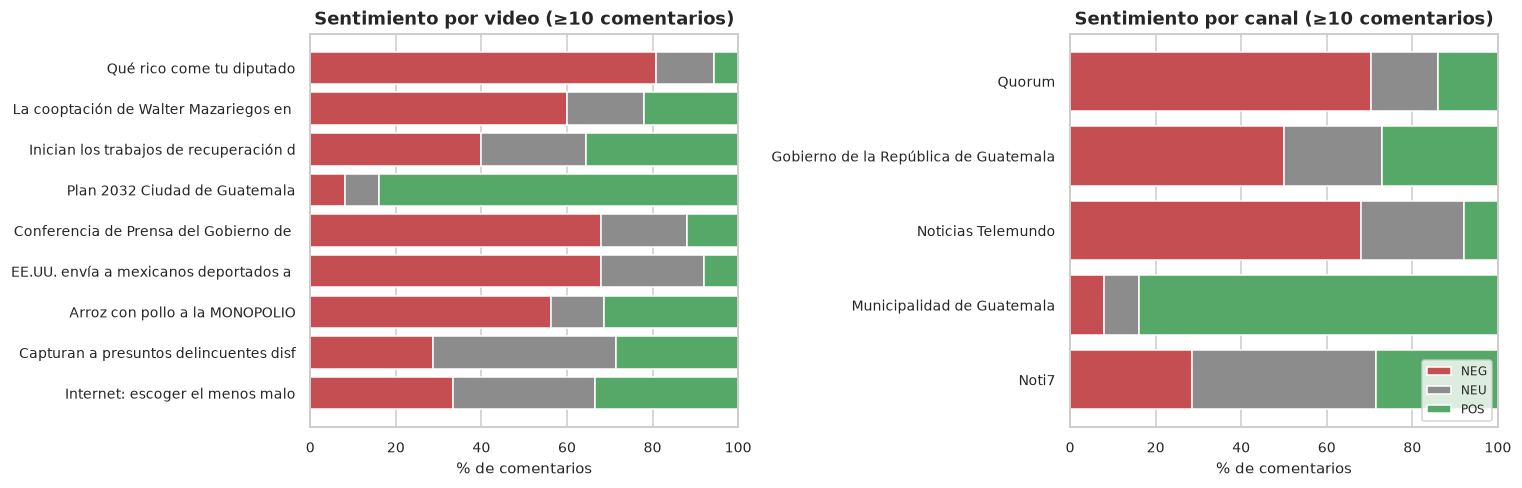

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
grafico_proporciones(por_video, f"Sentimiento por video (≥{UMBRAL} comentarios)", axes[0])
grafico_proporciones(por_canal, f"Sentimiento por canal (≥{UMBRAL} comentarios)", axes[1])
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Por canal, **5 de los 8 superan el umbral**, y el patrón se repite:

| Canal | Comentarios | % negativo |
| --- | --- | --- |
| Quorum | 256 | **70.3%** |
| Noticias Telemundo | 25 | 68.0% |
| Gobierno de la República | 70 | 50.0% |
| Noti7 | 14 | 28.6% |
| Municipalidad de Guatemala | 25 | **8.0%** |

**Nota**: Esto **NO significa que Quorum genere rechazo**, significa que los videos suyos que quedaron en la muestra tratan de gasto público y corrupción, temas que provocan comentarios críticos. La diferencia entre el 70.3% de Quorum y el 8.0% de la Municipalidad es mayormente una diferencia de **tema**, no de canal.

#### Sentimiento por comunidad (pendiente del inciso 7.5)

El Ejercicio 7 caracterizó las comunidades por videos, canales, autores, intensidad y temas, y dejó **el sentimiento pendiente** para este notebook. Aquí se completa esa caracterización.

In [14]:
resumen_com = (
    cv.dropna(subset=["comunidad"])
    .groupby("comunidad")
    .agg(comentarios=("comment_id", "size"),
         autores=("author_channel_id", "nunique"),
         canal=("channel_name", lambda s: s.mode().iat[0]),
         me_gusta=("like_count", "sum"))
)
sent_com = pd.crosstab(cv["comunidad"], cv["sentimiento"]).reindex(columns=ORDEN, fill_value=0)
resumen_com = resumen_com.join(sent_com)
for c in ORDEN:
    resumen_com[f"%{c}"] = (resumen_com[c] / resumen_com["comentarios"] * 100).round(1)
resumen_com = resumen_com.sort_values("comentarios", ascending=False)
resumen_com

,comentarios,autores,canal,me_gusta,NEG,NEU,POS,%NEG,%NEU,%POS
comunidad,,,,,,,,,,
0,159,125,Quorum,358,128,22,9,80.5,13.8,5.7
1,49,47,Quorum,89,30,8,11,61.2,16.3,22.4
3,43,30,Gobierno de la República de Guatemala,90,17,10,16,39.5,23.3,37.2
2,36,29,Quorum,20,18,9,9,50.0,25.0,25.0
4,25,25,Municipalidad de Guatemala,1697,2,2,21,8.0,8.0,84.0
5,25,18,Noticias Telemundo,25,17,6,2,68.0,24.0,8.0
6,25,18,Gobierno de la República de Guatemala,19,17,5,3,68.0,20.0,12.0
7,15,13,Noti7,12,4,7,4,26.7,46.7,26.7
8,8,7,PrensaLibreOficial,1,7,1,0,87.5,12.5,0.0


Las cifras completan la caracterización de las comunidades. Las tres mayores, todas del canal Quorum, resultan claramente distintas:

| Comunidad | Canal | Comentarios | % NEG | % POS |
| --- | --- | --- | --- | --- |
| 0 — *Qué rico come tu diputado* | Quorum | 159 | **80.5%** | 5.7% |
| 1 — *La cooptación de la USAC* | Quorum | 49 | 61.2% | 22.4% |
| 3 — *Recuperación del Puente Belice* | Gobierno | 43 | 39.5% | **37.2%** |
| 4 — *Plan 2032 Ciudad de Guatemala* | Municipalidad | 25 | 8.0% | **84.0%** |

Tal y como se demostró en el Ejercicio 7, **cada comunidad es el público de un video**. Ese resultado también es obtenido aquí, pero desde otro ángulo: el sentimiento se organiza por contenido. Dos comunidades del mismo canal (0 y 1) difieren en 19 puntos de negatividad porque hablan de cosas distintas.

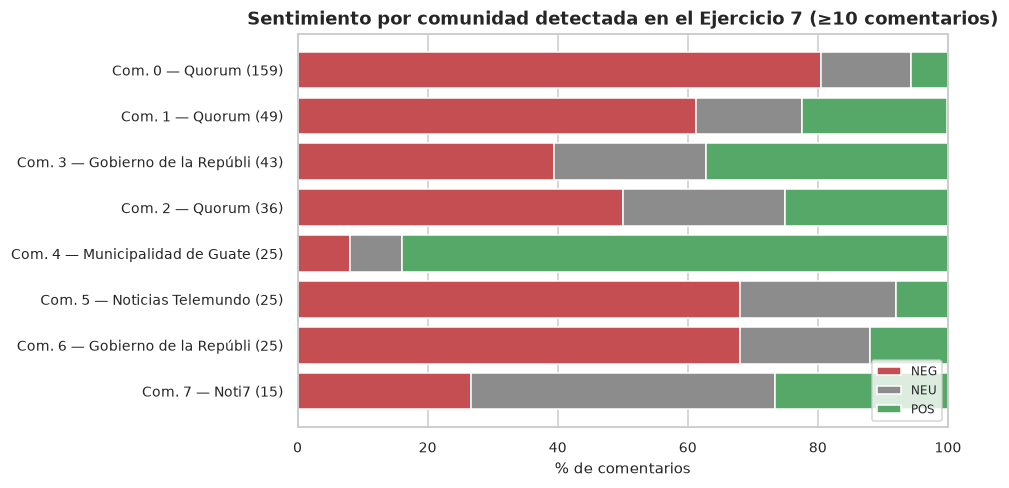

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.6))
sub = resumen_com[resumen_com["comentarios"] >= UMBRAL]
etiquetas = [f"Com. {int(i)} — {r['canal'][:22]} ({int(r['comentarios'])})"
             for i, r in sub.iterrows()]
abajo = np.zeros(len(sub))
for c in ORDEN:
    ax.barh(etiquetas[::-1], sub[f"%{c}"].values[::-1], left=abajo,
            color={"NEG": "#C44E52", "NEU": "#8C8C8C", "POS": "#55A868"}[c], label=c)
    abajo = abajo + sub[f"%{c}"].values[::-1]
ax.set_title(f"Sentimiento por comunidad detectada en el Ejercicio 7 (≥{UMBRAL} comentarios)")
ax.set_xlabel("% de comentarios")
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# Temas dominantes de cada comunidad, junto a su sentimiento
for i in sub.index[:3]:
    s = cv[cv["comunidad"] == i]
    tok = Counter(t for lista in s["tokens_comentario"] for t in lista)
    r = resumen_com.loc[i]
    print(f"COMUNIDAD {int(i)} — {r['canal']} | {int(r['comentarios'])} comentarios")
    print(f"   sentimiento: {r['%NEG']}% NEG | {r['%NEU']}% NEU | {r['%POS']}% POS")
    print(f"   temas:       {', '.join(p for p, _ in tok.most_common(10))}")
    print()

COMUNIDAD 0 — Quorum | 159 comentarios
   sentimiento: 80.5% NEG | 13.8% NEU | 5.7% POS
   temas:       pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo, trabajar, corrupto, ganar

COMUNIDAD 1 — Quorum | 49 comentarios
   sentimiento: 61.2% NEG | 16.3% NEU | 22.4% POS
   temas:       usac, corrupto, estudiante, universidad, excelente, información, universitario, sacar, seguir, pueblo

COMUNIDAD 3 — Gobierno de la República de Guatemala | 43 comentarios
   sentimiento: 39.5% NEG | 23.3% NEU | 37.2% POS
   temas:       presidente, año, guatemala, proyecto, terminar, bernardo, arevalo, puente, vivir, pais



**Cruce entre Temas y Sentimiento**

- **Comunidad 0** (*pueblo, diputado, pagar, sueldo, almuerzo*) → 80.5% negativo. Vocabulario de gasto público y reclamo.
- **Comunidad 1** (*usac, corrupto, estudiante, universidad, excelente*) → 61.2% negativo. Es crítica, pero incluye elogios al trabajo periodístico, lo que explica su 22.4% positivo.
- **Comunidad 3** (*presidente, proyecto, bernardo, arevalo, puente*) → casi empatada, 39.5% negativa y 37.2% positiva. Es la única comunidad **dividida** debido a una obra pública que genera apoyo y rechazo en proporciones similares.

In [17]:
por_categoria = sentimiento_por("category")
por_grupo = sentimiento_por("source_group_video")
print("Por categoría de YouTube:")
print(por_categoria[["total", "%NEG", "%NEU", "%POS"]].to_string())
print("\nPor procedencia del muestreo (source_group del video):")
print(por_grupo[["total", "%NEG", "%NEU", "%POS"]].to_string())

Por categoría de YouTube:
sentimiento            total  %NEG   %NEU  %POS
category                                       
News & Politics          335  64.2   17.0  18.8
Entertainment             70  50.0   22.9  27.1
Nonprofits & Activism      1   0.0  100.0   0.0

Por procedencia del muestreo (source_group del video):
sentimiento         total  %NEG  %NEU  %POS
source_group_video                         
topic                 363  63.4  18.2  18.5
channel                43  46.5  18.6  34.9


Por categoría, *News & Politics* es más negativa (64.2%) que *Entertainment* (50.0%), aunque debe notarse que los videos de "Entertainment" en esta muestra son conferencias de prensa del Gobierno, no entretenimiento puro. La etiqueta de YouTube no describe bien el contenido.

Por procedencia del muestreo, los videos hallados por tema son más negativos (63.4%) que los hallados por canal (46.5%). Esto demuestra que **la forma de recolectar condiciona lo que se observa**, incluso en el sentimiento.

### 9.3 Sentimiento frente a reacción recibida

Se cruza el sentimiento con las dos formas de reacción disponibles, para contrastar el hallazgo del Notebook 2, donde los comentarios más gustados resultaban breves y elogiosos.

In [18]:
reaccion = cv.groupby("sentimiento").agg(
    comentarios=("comment_id", "size"),
    me_gusta_totales=("like_count", "sum"),
    me_gusta_mediana=("like_count", "median"),
    me_gusta_medio=("like_count", "mean"),
    respuestas=("reply_count", "sum"),
    caracteres_mediana=("texto_original_comentario", lambda s: s.str.len().median()),
).reindex(ORDEN).round(2)
print(reaccion.to_string())
print("\nLos 5 comentarios con más 'me gusta' y su sentimiento:")
top = cv.nlargest(5, "like_count")[["like_count", "sentimiento", "sentimiento_prob", "texto_original_comentario"]]
for _, f in top.iterrows():
    print(f"  {int(f['like_count']):>4} me gusta | {f['sentimiento']} ({f['sentimiento_prob']:.2f}) | "
          f"{f['texto_original_comentario'][:78]}")

             comentarios  me_gusta_totales  me_gusta_mediana  me_gusta_medio  respuestas  caracteres_mediana
sentimiento                                                                                                 
NEG                  250               411               0.0            1.64          26               132.5
NEU                   74               557               1.0            7.53           9                40.0
POS                   82              1357               2.0           16.55          16                73.0

Los 5 comentarios con más 'me gusta' y su sentimiento:
   405 me gusta | NEU (0.75) | Quiero vivir en esa Guatemala :v
   329 me gusta | POS (0.98) | Que bueno que Guatemala sea una cuidad bonita y ojalá todos los proyectos sean
   211 me gusta | POS (0.91) | Me encantaría vivir por un tiempo en Guatemala.
Saludos desde México. :)
   191 me gusta | POS (0.97) | Que bella es la Ciudad de Guatemala, unica en su clase. 
Saludos desde El Salv
   113 me g

### Lo que recibe más reacción no es lo que más se dice

Este hallazgo es interesante y confirma con una medida directa lo que se descubrió en el Notebook 2.

| Sentimiento | Comentarios | "Me gusta" totales | Mediana | Media |
| --- | --- | --- | --- | --- |
| NEG | **250 (61.6%)** | 411 | 0.0 | 1.64 |
| NEU | 74 | 557 | 1.0 | 7.53 |
| POS | 82 (20.2%) | **1,357** | 2.0 | **16.55** |

Los comentarios negativos son **tres veces más numerosos** que los positivos, pero los positivos acumulan **más del triple de "me gusta"**, y un comentario positivo recibe en promedio diez veces más "me gusta" que uno negativo. Cuatro de los cinco comentarios más gustados son elogios a la Ciudad de Guatemala, varios firmados desde México, El Salvador y Ecuador.

También se ve que los comentarios negativos son los **más largos** (mediana de 132.5 caracteres frente a 73.0 de los positivos), lo cual hace sentido, pues una crítica se argumenta mientras que un elogio es breve.

Cabe resaltar que estos resultados son **descriptivos**. Los datos no permiten saber si el elogio *causa* más "me gusta"; los comentarios más gustados podrían ser simplemente los más antiguos o los mejor posicionados por el ordenamiento de YouTube, información que el conjunto no contiene.

### ¿Qué no captura este análisis?

El modelo fue entrenado con tuits en español general, **no guatemalteco**. No reconoce modismos locales, y sobre todo **no detecta la ironía**, que es abundante en la crítica política. Un comentario como *"Arroz con pollo a la MONOPOLIO"* es sarcástico y el modelo lo procesa literalmente. El 15.5% de clasificaciones con probabilidad baja da una idea del margen de error.

## Ejercicio 10. Interpretación, limitaciones y conclusiones

### 10.1 Los hallazgos reunidos

In [19]:
# Se reúnen las cifras clave producidas por los cuatro notebooks
videos = cargar("videos_limpio")
metricas = pd.read_csv(DATA_PROCESSED / "metricas_topologia.csv")
centralidades = pd.read_csv(DATA_PROCESSED / "centralidades.csv")

com_por_autor = cv.groupby("author_channel_id").size()
com_por_video = cv.groupby("video_id").size()

sintesis = pd.Series({
    "videos en el catálogo": len(videos),
    "videos con comentarios recolectados": cv["video_id"].nunique(),
    "canales en el catálogo": videos["channel_id"].nunique(),
    "canales con comentarios": cv["channel_id"].nunique(),
    "comentarios": len(cv),
    "autores distintos": cv["author_channel_id"].nunique(),
    "autores con un solo comentario (%)": round((com_por_autor == 1).mean() * 100, 1),
    "autores que comentaron en >1 video": int((cv.groupby("author_channel_id")["video_id"].nunique() > 1).sum()),
    "comentarios en el video más comentado (%)": round(com_por_video.max() / len(cv) * 100, 1),
    "comunidades detectadas": int(comunidades["comunidad"].nunique()),
    "comentarios negativos (%)": round((cv["sentimiento"] == "NEG").mean() * 100, 1),
    "comentarios positivos (%)": round((cv["sentimiento"] == "POS").mean() * 100, 1),
}, name="valor")
sintesis.to_frame()

,valor
videos en el catálogo,293.0
videos con comentarios recolectados,19.0
canales en el catálogo,97.0
canales con comentarios,8.0
comentarios,406.0
autores distintos,332.0
autores con un solo comentario (%),86.1
autores que comentaron en >1 video,9.0
comentarios en el video más comentado (%),39.7
comunidades detectadas,17.0


**¿Qué muestran estos datos sobre la participación y el consumo de contenido en YouTube?**

Reuniendo los cuatro notebooks, el panorama general es:

1. **La participación es amplia y superficial.** 332 personas escribieron 406 comentarios, y el **86.1% escribió uno solo**. No hay una comunidad de comentaristas habituales; hay mucha gente que pasa una vez y no vuelve.

2. **Lo que concentra la atención es el contenido, no las personas.** El coeficiente de Gini es 0.66 para videos y canales, pero solo 0.164 para autores. Un solo video reúne el **39.7%** de todos los comentarios. La desigualdad está en qué se comenta, no en quién comenta.

3. **La estructura es de estrellas, no de red social.** Los videos son los centros y los comentaristas los radios. Solo **9 de 332 autores** comentaron en más de un video, así que prácticamente no hay conexiones entre públicos. Las 17 comunidades detectadas son públicos de video, no grupos de personas.

4. **El sentimiento sigue al tema.** El 61.6% de los comentarios es negativo, pero ese promedio esconde extremos que van del 80.7% de negatividad en un video sobre gasto de diputados al 84% de positividad en uno sobre un plan urbano.

5. **La reacción premia lo contrario de lo que abunda.** La crítica domina en volumen; el elogio domina en "me gusta".

En conjunto, lo observado se parece menos a una conversación pública y más a **muchas reacciones individuales y paralelas frente a piezas de contenido**, sin apenas contacto entre quienes participan.

### 10.2 Limitaciones

In [20]:
# Cada limitación con la cifra que la respalda
lim = []

lim.append({"limitación": "Cobertura de comentarios",
            "evidencia": f"{cv['video_id'].nunique()} de {len(videos)} videos tienen comentarios "
                         f"({cv['video_id'].nunique()/len(videos):.1%})"})

q = cv["source_query_comentario"].value_counts()
lim.append({"limitación": "Selección por consultas",
            "evidencia": f"'{q.index[0]}' aporta {q.iloc[0]} de {len(cv)} comentarios ({q.iloc[0]/len(cv):.1%}); "
                         f"{int((videos['source_group'] == 'official_gov').sum())} videos official_gov aportan 0"})

lim.append({"limitación": "Fechas relativas",
            "evidencia": f"published_text tiene {cv['published_text'].nunique()} valores del tipo "
                         f"'{cv['published_text'].mode().iat[0]}': no son fechas"})

topes = com_por_video.value_counts()
lim.append({"limitación": "Conteos al momento de recolección",
            "evidencia": f"{int(topes.get(25, 0))} videos tienen exactamente 25 comentarios: "
                         "indicio de un tope de extracción"})

lim.append({"limitación": "Sin relaciones explícitas entre autores",
            "evidencia": f"{int(cv['reply_count'].sum())} respuestas declaradas, pero 0 columnas "
                         "que identifiquen a quién respondieron"})

lim.append({"limitación": "Concentración en pocos videos",
            "evidencia": f"el video más comentado aporta {com_por_video.max()} de {len(cv)} comentarios "
                         f"({com_por_video.max()/len(cv):.1%}) y el 75.7% de las aristas autor–autor"})

lim.append({"limitación": "Modelo de sentimiento no local",
            "evidencia": f"{int((cv['sentimiento_prob'] < 0.60).sum())} clasificaciones con probabilidad < 0.60; "
                         "el modelo se entrenó con español general, no guatemalteco"})

pd.DataFrame(lim)

,limitación,evidencia
0,Cobertura de comentarios,19 de 293 videos tienen comentarios (6.5%)
1,Selección por consultas,'@quorumgt/videos' aporta 231 de 406 comentari...
2,Fechas relativas,published_text tiene 39 valores del tipo 'hace...
3,Conteos al momento de recolección,3 videos tienen exactamente 25 comentarios: in...
4,Sin relaciones explícitas entre autores,"51 respuestas declaradas, pero 0 columnas que ..."
5,Concentración en pocos videos,el video más comentado aporta 161 de 406 comen...
6,Modelo de sentimiento no local,63 clasificaciones con probabilidad < 0.60; el...


**Limitaciones (con sus cifras)**

1. **Cobertura de comentarios.** Solo **19 de 293 videos (6.5%)** tienen comentarios recolectados. Todo el análisis de red y de sentimiento describe esos 19, no el catálogo. Los 274 restantes no son videos sin comentarios, más bien son videos **sobre los que no se sabe nada**.

2. **Selección por consultas.** Una sola consulta, `@quorumgt/videos`, aporta **231 de los 406 comentarios (56.9%)**. Que Quorum domine todos los resultados es consecuencia del muestreo, no un hallazgo sobre YouTube en Guatemala. Y los **105 videos de canales oficiales de gobierno** no aportaron ni un comentario.

3. **Fechas relativas.** `published_text` guarda expresiones como *"hace 2 años"*, que dependen del momento del scraping. **No es posible ningún análisis temporal**; ni de evolución del sentimiento, ni de orden de llegada de los comentarios, ni de ritmo de la conversación.

4. **Conteos observados al momento de la recolección.** `view_count` acumula desde la publicación, mientras los comentarios son una captura del momento; los videos tienen antigüedades distintas, así que los dos conteos no son comparables. Además, **3 videos tienen exactamente 25 comentarios**, lo que indica un tope en la extracción (la participación de los videos más comentados está recortada).

5. **Sin relaciones explícitas entre autores.** Hay **51 respuestas declaradas**, pero ninguna columna dice quién respondió a quién. Por eso la única red posible entre autores es una proyección, cuyo carácter artificial quedó demostrado en el Ejercicio 5: sus 10,732 aristas se explican casi por completo por la aritmética de los grupos completos.

6. **Concentración en pocos videos.** Un solo video aporta **161 de 406 comentarios (39.7%)** y el **75.7%** de las aristas de la proyección autor–autor. Cualquier promedio del conjunto está dominado por ese video.

7. **El modelo de sentimiento no es local.** Fue entrenado con español general y **63 clasificaciones (15.5%) tienen probabilidad menor a 0.60**. No detecta ironía ni modismos guatemaltecos.

### 10.3 Descripción, asociación e inferencia

In [21]:
from scipy.stats import spearmanr

g = cv.groupby("video_id").agg(comentarios=("comment_id", "size"), vistas=("view_count", "first"))
rho, pval = spearmanr(g["vistas"], g["comentarios"])

print("DESCRIPCIÓN — lo que los datos dicen directamente")
print(f"  el {(com_por_autor == 1).mean():.1%} de los autores observados escribió un solo comentario")
print(f"  el {(cv['sentimiento'] == 'NEG').mean():.1%} de los comentarios fue clasificado como negativo")
print()
print("ASOCIACIÓN — lo que va junto, sin implicar causa")
print(f"  entre los {len(g)} videos con comentarios, vistas y comentarios covarían: "
      f"Spearman = {rho:.3f} (p = {pval:.5f})")
print(f"  sobre {len(g)} puntos y solo entre videos que sí fueron recolectados")
print()
print("INFERENCIA — lo que NO puede afirmarse")
print(f"  la muestra son {cv['author_channel_id'].nunique()} cuentas en {cv['video_id'].nunique()} videos "
      f"hallados por {cv['source_query_comentario'].nunique()} consultas")
print("  no describe a los usuarios de YouTube en Guatemala ni a la opinión pública guatemalteca")

DESCRIPCIÓN — lo que los datos dicen directamente
  el 86.1% de los autores observados escribió un solo comentario
  el 61.6% de los comentarios fue clasificado como negativo

ASOCIACIÓN — lo que va junto, sin implicar causa
  entre los 19 videos con comentarios, vistas y comentarios covarían: Spearman = 0.811 (p = 0.00002)
  sobre 19 puntos y solo entre videos que sí fueron recolectados

INFERENCIA — lo que NO puede afirmarse
  la muestra son 332 cuentas en 19 videos hallados por 6 consultas
  no describe a los usuarios de YouTube en Guatemala ni a la opinión pública guatemalteca


**Existen tres niveles bastante diferenciados.**

| Nivel | Qué es | Ejemplo de este trabajo |
| --- | --- | --- |
| **Descripción** | Un recuento de lo observado. No requiere supuestos | *"El 86.1% de los autores observados escribió un solo comentario"* · *"El 61.6% de los comentarios fue clasificado como negativo"* |
| **Asociación** | Dos cosas varían juntas. **No implica causa** | *"Entre estos 19 videos, más visualizaciones se acompañan de más comentarios (Spearman 0.811)"*. No se afirma que las vistas produzcan comentarios (ambos podrían depender del tema, del canal o de la antigüedad) |
| **Inferencia** | Extender lo observado a una población mayor. (**Aquí no procede**) | La muestra son 332 cuentas en 19 videos hallados por 6 consultas. No es una muestra aleatoria de nada |

**Lo que este trabajo no afirma**:

- No se describe a *los usuarios de YouTube en Guatemala*. Se describe a 332 cuentas que comentaron en 19 videos concretos.
- No se mide *la opinión pública guatemalteca*. Quien comenta en YouTube es una minoría autoseleccionada, y quien comenta suele hacerlo porque algo le molestó o le entusiasmó.
- No se afirma que *los guatemaltecos sean negativos*. El 61.6% de negatividad corresponde a una muestra dominada por videos sobre gasto público y corrupción.
- No se mide *influencia*. Las medidas de centralidad describen posiciones en una red de co-participación, no capacidad de persuadir a nadie.

---

### 10.4 Conclusiones

- La participación observada no forma una red social entre personas, sino un conjunto de **estrellas** (cada video es un centro y sus comentaristas son radios que no se tocan). El 97.3% de los autores tiene grado 1, y las 17 comunidades detectadas por Louvain (modularidad 0.777) resultaron ser públicos de video, no grupos de gente. La red es además **frágil** (basta eliminar un solo video para partirla en 127 piezas).

- Quien publica y quien comenta usan lenguajes distintos. Los videos hablan en términos institucionales (*conferencia prensa*, *gobierno guatemala*); los comentarios, en términos de dinero público y crítica política (*pueblo*, *diputado*, *corrupto*, *pagar sueldo*). Los hashtags son un recurso de quien publica (586 en los videos frente a 1 en los comentarios).

- El 61.6% de los comentarios es negativo, pero el promedio es una cifra engañosa, pues el signo lo determina el **tema del video**, con extremos que van del 80.7% de negatividad en uno sobre el gasto de los diputados al 84% de positividad en uno sobre un plan urbano. Y lo que predomina en volumen no es lo que predomina en aprobación (la crítica es tres veces más frecuente, pero el elogio recibe más del triple de "me gusta").

- La estructura de estrellas explica por qué el sentimiento se agrupa por video. Si los comentaristas no se conectan entre sí, no hay un "clima de opinión" compartido que cruce contenidos, sino tantas reacciones separadas como videos. Y la concentración de la participación explica por qué un solo video puede mover el promedio general de sentimiento de todo el conjunto.

- Todo lo anterior describe **19 videos de 293**, con el 56.9% de los comentarios provenientes de una sola consulta de búsqueda, sin información temporal utilizable y sin relaciones explícitas entre autores. La forma de recolectar los datos determinó buena parte de lo que se pudo encontrar.